# Quick Stock Snapshot

Use this notebook to quickly compare one or more stocks over a selected time period.

What you can change:

- `tickers`: one or more Yahoo Finance symbols, for example `AAPL`, `MSFT`, `NVDA`, `GOOGL`.
- `start_date`: first date in `YYYY-MM-DD` format.
- `end_date`: final date in `YYYY-MM-DD` format, or `None` for the latest available data.

The chart normalizes every stock to 100 on the first available date, so the lines show comparable percentage performance.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

# Find the project root whether this notebook is opened from the repo root
# or from quick_views/notebooks.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next(path for path in candidates if (path / "utils.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from quick_views.stock_snapshot import build_stock_snapshot, plot_snapshot

def format_price(value):
    """Format price values without requiring pandas Styler/jinja2."""
    if pd.isna(value):
        return ""
    return f"{value:,.2f}"

def format_percent(value):
    """Format decimal returns and risk metrics as percentages."""
    if pd.isna(value):
        return ""
    return f"{value:.2%}"


print(f"Project root: {project_root}")

Project root: C:\Users\lnazareno\OneDrive - European Banking Authority\Documents\Projects\financial_analysis


## Inputs

Edit this cell and rerun the cells below.

Date rules:

- Use text dates like `"2024-01-01"`.
- Use `None` for `end_date` when you want the latest available market data.

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL"]
start_date = "2024-01-01"
end_date = None

## Summary Table

- `period_return`: total return over the selected period.
- `annualized_volatility`: volatility scaled to one year using roughly 252 trading days.
- `max_drawdown`: worst fall from a previous high during the period.

In [3]:
prices, normalized, summary = build_stock_snapshot(tickers, start_date, end_date)

summary_display = summary.copy()

for column in ["first_close", "latest_close", "period_high", "period_low"]:
    summary_display[column] = summary_display[column].map(format_price)

for column in ["period_return", "annualized_volatility", "max_drawdown"]:
    summary_display[column] = summary_display[column].map(format_percent)

display(summary_display)

,ticker,first_close,latest_close,period_return,annualized_volatility,max_drawdown,period_high,period_low
0,AAPL,183.56,310.39,69.09%,27.22%,-33.36%,312.51,163.36
1,GOOGL,137.04,382.52,179.14%,30.26%,-29.81%,402.62,130.32
2,MSFT,363.80,443.15,21.81%,24.13%,-33.91%,538.66,351.11
3,NVDA,48.14,216.82,350.41%,48.88%,-36.88%,235.74,47.54


## Chart

The upper chart shows normalized performance. The lower chart shows total return over the selected period.

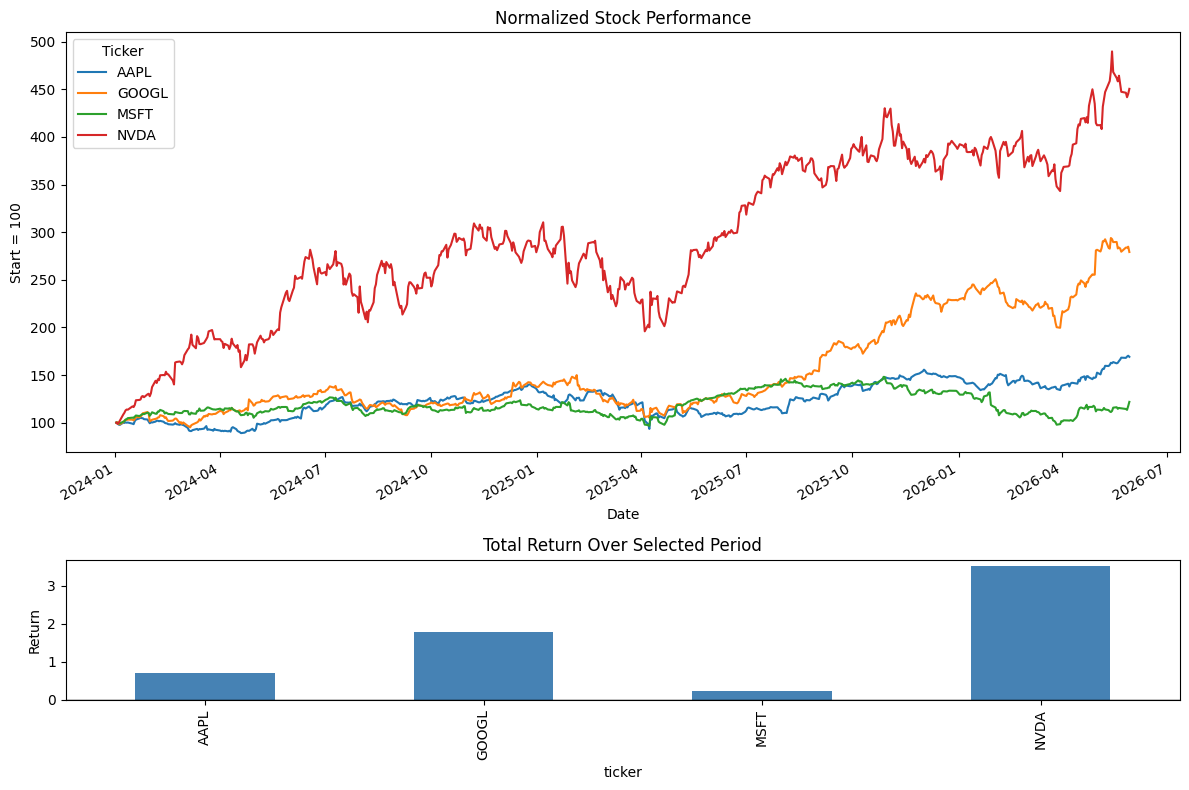

In [4]:
plot_snapshot(normalized, summary)

## Optional: Inspect The Latest Normalized Values

This is useful when you want to see the actual time-series data behind the chart.

In [5]:
normalized.tail()

Ticker,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2026-05-22,168.237274,279.463888,115.054508,447.312845
2026-05-26,167.970323,283.776582,114.356323,446.336494
2026-05-27,169.343166,283.740083,113.432746,441.641725
2026-05-28,170.247494,284.688742,117.368953,445.069318
2026-05-29,169.092574,279.135501,121.812312,450.408087
